# Cell Compartment Analysis - Pixel Overlap Method

This notebook analyzes the distribution of cell classes across tissue compartments using a pixel overlap threshold approach.

**Method**: Cells are assigned to a compartment if >50% of their pixels overlap with that compartment.

## Compartment Mapping:
- Epidermis: 13107
- Dermis: 39321
- Cartilage: 26214
- Follicles: 52428
- Blood_vessels: 65535

## 1. Import Libraries

In [65]:
import pandas as pd
import numpy as np
from pathlib import Path
from tifffile import imread
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import statsmodels
import scanpy as sc
import anndata

# Set display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [66]:
minMark = sc.read(r"D:\Dom\SpaceC test\outputs\Added_WT_M\doubleZ_clusters_minMark.h5ad")

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\dbuxton\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
#format adata object so that it is the same as the CellTune csvs. 
minMark = minMark.obs.drop(['dapi', 'Y', 'X', 'Area', 'bbox_y0', 'bbox_x0', 'bbox_y1', 'bbox_x1', 'region_num'], axis = 'columns')


new_cols = {'unique_region':'fov', 'leiden_0.24':'class', 'CellID':'cellID'}
new_order = ['class', 'fov', 'cellID']
minMark = minMark.rename(columns = new_cols)
minMark = minMark.reindex(columns = new_order)

#explicitly have classes/fovs as strings
minMark = minMark.astype(str)

minMark.to_csv(r"D:\Dom\SpaceC test\outputs\Added_WT_M\minMark_classes.csv", index = False)
minMark

,class,fov,cellID
0,7,0,8
1,0,0,9
2,7,0,10
3,0,0,11
4,0,0,12
...,...,...,...
5626,12,10,5844
5627,0,10,5845
5628,0,10,5846
5629,5,10,5847


# Define Functions

## 2. Define Compartment Mapping

In [67]:
# Define compartment mapping (grayscale value -> compartment name)
##use the first if using segmentation labels
COMPARTMENT_MAPPING = {
    13107: 'Epidermis',
    39321: 'Dermis',
    26214: 'Cartilage',
    52428: 'Follicles',
    65535: 'BloodVessels'
}

# List of subregion grayscale values
SUBREGION_VALUES = list(COMPARTMENT_MAPPING.keys())

print("Compartment mapping defined:")
for value, name in COMPARTMENT_MAPPING.items():
    print(f"  {name}: {value}")

Compartment mapping defined:
  Epidermis: 13107
  Dermis: 39321
  Cartilage: 26214
  Follicles: 52428
  BloodVessels: 65535


## 3. Define Functions for Compartment Cell Assignment

In [68]:
def get_cells_in_compartment(cell_masks, tissue_annotations, compartment_value, overlap_threshold=0.5):
    """
    Get list of cell IDs that belong to a specific compartment.
    A cell is assigned to a compartment if >overlap_threshold of its pixels are in that compartment.
    
    Args:
        cell_masks: 2D array where each cell has a unique integer ID
        tissue_annotations: 2D array with compartment labels (subregion image)
        compartment_value: Grayscale value of the compartment (e.g., 39321 for Dermis)
        overlap_threshold: Minimum fraction of cell pixels in compartment (default 0.5)
    
    Returns:
        List of cell IDs in this compartment
    """
    # Create a copy of annotations
    annotations = np.copy(tissue_annotations)
    
    # Zero out all regions except the one we're interested in
    annotations[annotations != compartment_value] = 0
    
    # Shift the compartment pixels to a high value
    shift = (np.max(cell_masks) + 1)
    annotations[annotations == compartment_value] = shift
    
    # Add cell masks and annotations
    marked_cells = cell_masks + annotations
    marked_cells = marked_cells.flatten()
    
    # Count occurrences of each value
    marked_cells_bincount = np.bincount(marked_cells)
    
    # Find cells where >overlap_threshold of pixels are in this compartment
    region_count = []
    for index in range(1, (len(marked_cells_bincount) - shift)):
        # marked_cells_bincount[index+shift] = pixels of cell 'index' in the compartment
        # marked_cells_bincount[index] = pixels of cell 'index' outside the compartment
        total_cell_pixels = marked_cells_bincount[index + shift] + marked_cells_bincount[index]
        if total_cell_pixels > 0:
            overlap_fraction = marked_cells_bincount[index + shift] / total_cell_pixels
            if overlap_fraction > overlap_threshold:
                region_count.append(index)
    
    return region_count

In [69]:
def get_all_compartment_cells(cell_masks, tissue_annotations, overlap_threshold=0.5):
    """
    Get cell ID lists for all compartments in an image.
    
    Args:
        cell_masks: 2D array where each cell has a unique integer ID
        tissue_annotations: 2D array with compartment labels
        overlap_threshold: Minimum fraction of cell pixels in compartment (default 0.5)
    
    Returns:
        Dictionary mapping compartment names to lists of cell IDs
        e.g., {'Dermis': [1, 5, 7, ...], 'Epidermis': [2, 3, 6, ...], ...}
    """
    compartment_cells = {}
    
    for compartment_value, compartment_name in COMPARTMENT_MAPPING.items():
        cell_ids = get_cells_in_compartment(
            cell_masks, 
            tissue_annotations, 
            compartment_value, 
            overlap_threshold
        )
        compartment_cells[compartment_name] = cell_ids
        print(f"  {compartment_name}: {len(cell_ids)} cells")
    
    return compartment_cells

## 4. Process All FOVs and Build Cell ID Dictionary

In [70]:
def process_all_fovs(fov_folder_path, overlap_threshold=0.5):
    """
    Process all FOV folders and build dictionary of cell IDs per compartment.
    
    Args:
        fov_folder_path: Path to parent folder containing FOV subfolders
        overlap_threshold: Minimum fraction of cell pixels in compartment
    
    Returns:
        Dictionary with structure:
        {
            'fov1': {
                'Dermis': [cell_id1, cell_id2, ...],
                'Epidermis': [cell_id1, cell_id2, ...],
                ...
            },
            'fov2': {...},
            ...
        }
    """
    fov_folder_path = Path(fov_folder_path)
    all_fov_data = {}
    
    # Find all FOV folders (directories containing segmentation_labels.tiff)
    fov_folders = []
    for folder in fov_folder_path.iterdir():
        if folder.is_dir():
            seg_path = folder / 'segmentation_labels.tiff'
            if seg_path.exists():
                fov_folders.append(folder)
    
    print(f"Found {len(fov_folders)} FOV folders")
    print("="*80)
    
    # Process each FOV
    for fov_folder in sorted(fov_folders):
        fov_name = fov_folder.name
        print(f"\nProcessing {fov_name}...")
        
        # Load images
        segmentation_path = fov_folder / 'segmentation_labels.tiff'
        subregions_path = fov_folder / 'treated_mask.tif' 
        
        if not subregions_path.exists():
            print(f"  Warning: {subregions_path} not found, skipping")
            continue
        
        # Load the images
        cell_masks = imread(str(segmentation_path))
        tissue_annotations = imread(str(subregions_path))
        
        print(f"  Segmentation shape: {cell_masks.shape}")
        print(f"  Subregions shape: {tissue_annotations.shape}")
        print(f"  Total cells: {len(np.unique(cell_masks)) - 1}")  # -1 for background
        
        # Get cell IDs for each compartment
        compartment_cells = get_all_compartment_cells(
            cell_masks, 
            tissue_annotations, 
            overlap_threshold
        )
        
        all_fov_data[fov_name] = compartment_cells
    
    print("\n" + "="*80)
    print("Processing complete!")
    return all_fov_data

## 5. Count Cell Classes per Compartment

In [71]:
def count_cell_classes_in_compartments(all_fov_data, cell_metadata_df):
    """
    Count how many cells of each class exist in each compartment for each FOV.
    
    Args:
        all_fov_data: Dictionary from process_all_fovs()
        cell_metadata_df: DataFrame with columns [fov, CellID, class]
    
    Returns:
        Dictionary with structure:
        {
            'fov1': {
                'Dermis_CD45': 25,
                'Dermis_CD3': 10,
                'Epidermis_CD45': 5,
                ...
            },
            ...
        }
    """
    class_counts = {}
    
    for fov_name, compartment_data in all_fov_data.items():
        fov_counts = {}
        
        # Get metadata for this FOV
        fov_metadata = cell_metadata_df[cell_metadata_df['fov'] == fov_name].copy()
        fov_metadata['cellID'] = fov_metadata['cellID'].astype(int)
        
        # For each compartment
        for compartment_name, cell_id_list in compartment_data.items():
            # Filter metadata to only cells in this compartment
            compartment_cells = fov_metadata[fov_metadata['cellID'].isin(cell_id_list)]
            
            # Count each class
            class_counts_series = compartment_cells['class'].value_counts()
            
            for cell_class, count in class_counts_series.items():
                key = f"{compartment_name}_{cell_class}"
                fov_counts[key] = count
        
        class_counts[fov_name] = fov_counts
    
    return class_counts

In [72]:
def create_counts_dataframe(class_counts):
    """
    Convert the class counts dictionary to a tidy DataFrame for plotting.
    
    Args:
        class_counts: Dictionary from count_cell_classes_in_compartments()
    
    Returns:
        DataFrame with columns [fov, compartment, class, count]
    """
    rows = []
    
    for fov_name, fov_data in class_counts.items():
        for key, count in fov_data.items():
            # Parse the key (e.g., 'Dermis_CD45' -> compartment='Dermis', class='CD45')
            parts = key.split('_', 1)
            if len(parts) == 2:
                compartment, cell_class = parts
                rows.append({
                    'fov': fov_name,
                    'compartment': compartment,
                    'class': cell_class,
                    'count': count
                })
    
    return pd.DataFrame(rows)

In [73]:
# Get total cell counts for each FOV from segmentation images
def get_total_cells_per_fov(fov_folder_path):
    """
    Get total number of cells in each FOV from segmentation images.
    """
    fov_folder_path = Path(fov_folder_path)
    total_cells = {}
    
    for folder in sorted(fov_folder_path.iterdir()):
        if folder.is_dir():
            seg_path = folder / 'segmentation_labels.tiff'
            if seg_path.exists():
                segmentation = imread(str(seg_path))
                unique_cells = np.unique(segmentation)
                n_cells = len(unique_cells) - 1  # -1 to exclude background
                total_cells[folder.name] = n_cells
    
    return total_cells

# 6. Configuration - Set Your Paths

In [74]:
# UPDATE THESE PATHS
FOV_FOLDER_PATH = r"D:\Dom\Psoriasis project\4th year data\CellTune\CellTune_Data\Images\registered images"  # Parent folder containing FOV subfolders (e.g., R7r2, R7r3, etc.)
CELL_METADATA_CSV = r"D:\Dom\SpaceC test\outputs\Added_WT_M\minMark_classes.csv"  # CSV with columns: fov, CellID, class
OVERLAP_THRESHOLD = 0.5  # Cells must have >50% of pixels in compartment to be counted

print(f"FOV Folder: {FOV_FOLDER_PATH}")
print(f"Cell Metadata CSV: {CELL_METADATA_CSV}")
print(f"Overlap Threshold: {OVERLAP_THRESHOLD}")

FOV Folder: D:\Dom\Psoriasis project\4th year data\CellTune\CellTune_Data\Images\registered images
Cell Metadata CSV: D:\Dom\SpaceC test\outputs\Added_WT_M\minMark_classes.csv
Overlap Threshold: 0.5


In [75]:
#define the replacement key
# Define the replacement key as a dictionary
replacement_key = {
    # old_name: new_name
    'R2r1': 'WT_F',
    'R3r1': 'D3_F',
    'R3r2': 'D3_M',
    'R4r1': 'D7_F',
    'R4r2': 'D7_M',
    'R5r1': 'D10_F',
    'R5r2': 'D10_M',
    'R6r1': 'D7_F2',
    'R6r2': 'D7_M2',
    'R7r2': 'D7_M3',
    'R8r2': 'WT_M'
}


In [76]:
# Calculate total cells and apply name replacement
fov_total_cells = get_total_cells_per_fov(FOV_FOLDER_PATH)

#renaming
fov_total_cells_renamed = {replacement_key.get(k, k): v for k, v in fov_total_cells.items()}
fov_total_cells_renamed

{'WT_F': 7396,
 'D3_F': 7922,
 'D3_M': 8308,
 'D7_F': 10606,
 'D7_M': 14517,
 'D10_F': 8774,
 'D10_M': 10505,
 'D7_F2': 11091,
 'D7_M2': 13460,
 'D7_M3': 10677,
 'WT_M': 5849}

## 7. Load Cell Metadata

In [56]:
# Load cell metadata (from celltune CSV)
cell_metadata_df = pd.read_csv(CELL_METADATA_CSV, dtype = str)

print(f"Loaded {len(cell_metadata_df)} cells")
print(f"FOVs in metadata: {sorted(cell_metadata_df['fov'].unique())}")
print(f"Cell classes: {sorted(cell_metadata_df['class'].unique())}")
print("\nFirst 5 rows:")
cell_metadata_df.head()

Loaded 105773 cells
FOVs in metadata: ['0', '1', '10', '2', '3', '4', '5', '6', '7', '8', '9']
Cell classes: ['0', '1', '10', '11', '12', '13', '2', '3', '4', '5', '6', '7', '8', '9']

First 5 rows:


,class,fov,cellID
0,7,0,8
1,0,0,9
2,7,0,10
3,0,0,11
4,0,0,12


In [57]:
#for those from an anndata object 
new_fov_names = {'0':'R2r1', '1':'R3r1', '2':'R3r2', '3':'R4r1', '4':'R4r2', '5':'R5r1', '6':'R5r2', '7':'R6r1', '8':'R6r2', '9':'R7r2', '10': 'R8r2'}
cell_metadata_df['fov'] = cell_metadata_df['fov'].replace(new_fov_names)


cell_metadata_df

,class,fov,cellID
0,7,R2r1,8
1,0,R2r1,9
2,7,R2r1,10
3,0,R2r1,11
4,0,R2r1,12
...,...,...,...
105768,12,R8r2,5844
105769,0,R8r2,5845
105770,0,R8r2,5846
105771,5,R8r2,5847


## 8. Process All FOVs - Get Cell IDs per Compartment

In [77]:
# Process all FOVs and get cell ID lists for each compartment
all_fov_data = process_all_fovs(FOV_FOLDER_PATH, OVERLAP_THRESHOLD)

Found 11 FOV folders

Processing R2r1...
  Segmentation shape: (3024, 10056)
  Subregions shape: (3024, 10056)
  Total cells: 7396
  Epidermis: 1986 cells
  Dermis: 2993 cells
  Cartilage: 1700 cells
  Follicles: 478 cells
  BloodVessels: 215 cells

Processing R3r1...
  Segmentation shape: (1500, 9024)
  Subregions shape: (1500, 9024)
  Total cells: 7922
  Epidermis: 1384 cells
  Dermis: 2442 cells
  Cartilage: 1743 cells
  Follicles: 295 cells
  BloodVessels: 88 cells

Processing R3r2...
  Segmentation shape: (984, 9456)
  Subregions shape: (984, 9456)
  Total cells: 8308
  Epidermis: 1210 cells
  Dermis: 1671 cells
  Cartilage: 1716 cells
  Follicles: 324 cells
  BloodVessels: 64 cells

Processing R4r1...
  Segmentation shape: (1320, 9612)
  Subregions shape: (1320, 9612)
  Total cells: 10606
  Epidermis: 2434 cells
  Dermis: 2883 cells
  Cartilage: 1879 cells
  Follicles: 1235 cells
  BloodVessels: 168 cells

Processing R4r2...
  Segmentation shape: (1668, 9336)
  Subregions shape: 

In [78]:
# Inspect the structure for one FOV
example_fov = list(all_fov_data.keys())[0]
print(f"Example structure for {example_fov}:")
print("\nCompartments and number of cells:")
for compartment, cell_list in all_fov_data[example_fov].items():
    print(f"  {compartment}: {len(cell_list)} cells")
    print(f"    First 10 cell IDs: {cell_list[:10]}")


list(all_fov_data.keys())

Example structure for R2r1:

Compartments and number of cells:
  Epidermis: 1986 cells
    First 10 cell IDs: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Dermis: 2993 cells
    First 10 cell IDs: [45, 53, 54, 56, 57, 60, 62, 64, 65, 66]
  Cartilage: 1700 cells
    First 10 cell IDs: [119, 121, 125, 137, 138, 139, 140, 144, 145, 148]
  Follicles: 478 cells
    First 10 cell IDs: [1241, 1252, 1255, 1256, 1265, 1267, 1280, 1293, 1296, 1320]
  BloodVessels: 215 cells
    First 10 cell IDs: [575, 588, 597, 605, 613, 631, 637, 655, 666, 675]


['R2r1',
 'R3r1',
 'R3r2',
 'R4r1',
 'R4r2',
 'R5r1',
 'R5r2',
 'R6r1',
 'R6r2',
 'R7r2',
 'R8r2']

## 9. Count Cell Classes in Each Compartment

In [79]:
# Count cell classes in each compartment for each FOV
class_counts = count_cell_classes_in_compartments(all_fov_data, cell_metadata_df)

# Show example
print(f"Example counts for {example_fov}:")
for key, count in sorted(class_counts[example_fov].items()):
    print(f"  {key}: {count}")

Example counts for R2r1:
  BloodVessels_0: 51
  BloodVessels_1: 9
  BloodVessels_2: 4
  BloodVessels_3: 5
  BloodVessels_4: 6
  BloodVessels_6: 120
  BloodVessels_9: 1
  Cartilage_0: 322
  Cartilage_1: 879
  Cartilage_10: 225
  Cartilage_11: 13
  Cartilage_13: 1
  Cartilage_2: 8
  Cartilage_3: 8
  Cartilage_4: 103
  Cartilage_5: 1
  Cartilage_6: 5
  Cartilage_8: 62
  Dermis_0: 910
  Dermis_1: 327
  Dermis_10: 12
  Dermis_11: 13
  Dermis_12: 10
  Dermis_13: 3
  Dermis_2: 188
  Dermis_3: 603
  Dermis_4: 141
  Dermis_5: 6
  Dermis_6: 172
  Dermis_8: 84
  Epidermis_0: 822
  Epidermis_1: 14
  Epidermis_11: 8
  Epidermis_2: 238
  Epidermis_3: 63
  Epidermis_4: 295
  Epidermis_5: 149
  Epidermis_7: 129
  Epidermis_8: 137
  Epidermis_9: 79
  Follicles_0: 283
  Follicles_1: 28
  Follicles_10: 2
  Follicles_11: 3
  Follicles_12: 1
  Follicles_2: 18
  Follicles_3: 11
  Follicles_4: 54
  Follicles_5: 34
  Follicles_6: 2
  Follicles_7: 19
  Follicles_8: 16
  Follicles_9: 4


In [81]:
# Convert to DataFrame for easier analysis and plotting
counts_df = create_counts_dataframe(class_counts)


# Calculate total cells and apply name replacement
fov_total_cells = get_total_cells_per_fov(FOV_FOLDER_PATH)
fov_total_cells_renamed = {replacement_key.get(k, k): v for k, v in fov_total_cells.items()}

print(f"Total rows in counts DataFrame: {len(counts_df)}")
print("\nFirst 20 rows:")
counts_df.head(20)

Total rows in counts DataFrame: 603

First 20 rows:


,fov,compartment,class,count
0,R2r1,Epidermis,0,822
1,R2r1,Epidermis,4,295
2,R2r1,Epidermis,2,238
3,R2r1,Epidermis,5,149
4,R2r1,Epidermis,8,137
5,R2r1,Epidermis,7,129
6,R2r1,Epidermis,9,79
7,R2r1,Epidermis,3,63
8,R2r1,Epidermis,1,14
9,R2r1,Epidermis,11,8


In [82]:
# Replace FOV names with biologically relevant names (replacement key defined in configuration section)

# Apply the replacement to counts_df
counts_df['fov'] = counts_df['fov'].replace(replacement_key)

# Verify the replacement worked
print("Updated FOV names:")
print(counts_df['fov'].unique())
print("\nFirst few rows after replacement:")
counts_df.head(10)

Updated FOV names:
['WT_F' 'D3_F' 'D3_M' 'D7_F' 'D7_M' 'D10_F' 'D10_M' 'D7_F2' 'D7_M2'
 'D7_M3' 'WT_M']

First few rows after replacement:


,fov,compartment,class,count
0,WT_F,Epidermis,0,822
1,WT_F,Epidermis,4,295
2,WT_F,Epidermis,2,238
3,WT_F,Epidermis,5,149
4,WT_F,Epidermis,8,137
5,WT_F,Epidermis,7,129
6,WT_F,Epidermis,9,79
7,WT_F,Epidermis,3,63
8,WT_F,Epidermis,1,14
9,WT_F,Epidermis,11,8


In [ ]:
# Save results
counts_df.to_csv(r"D:\Dom\SpaceC test\outputs\Added_WT_M\minMark_class_counts.csv", index=False)


In [84]:
counts_df['class'].unique()

array(['0', '4', '2', '5', '8', '7', '9', '3', '1', '11', '6', '10', '12',
       '13'], dtype=object)

# 10. Visualizations

### 10.1 Bar Plot: Specific Cell Class Across FOVs

PLOT 1: Total CD45 as Percentage of Total Cells


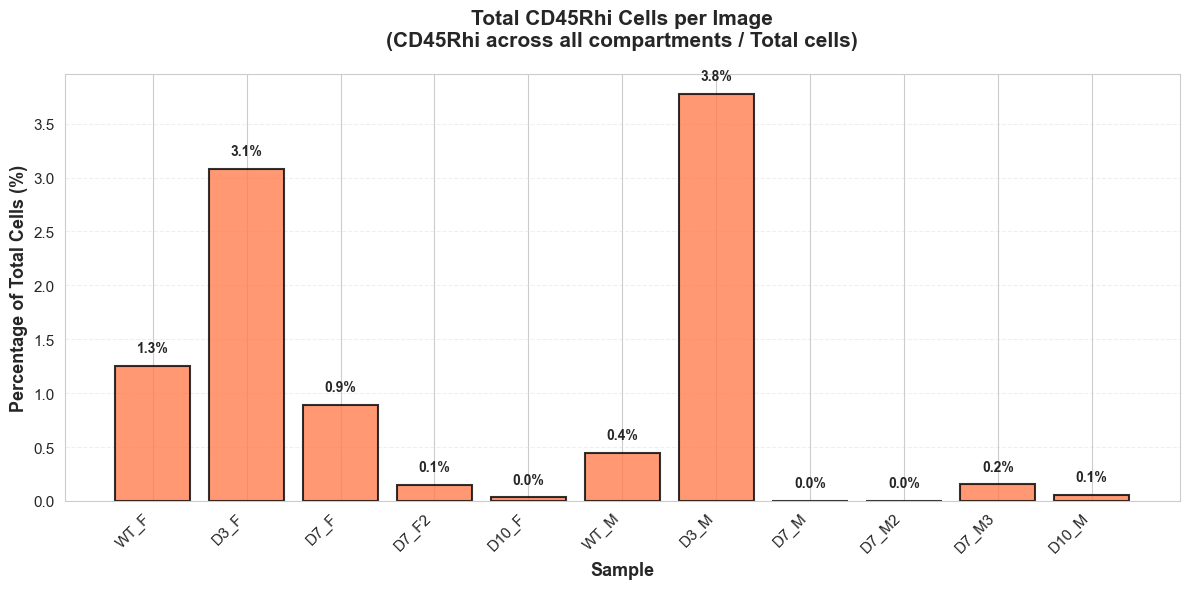


Statistics for Total CD45Rhi as % of total cells:
  Mean: 0.89%
  Std: 1.33%
  Min: 0.00%
  Max: 3.77%

Detailed breakdown:
  WT_F: 84.0 CD45Rhi / 6701 total = 1.25%
  D3_F: 181.0 CD45Rhi / 5870 total = 3.08%
  D7_F: 75.0 CD45Rhi / 8415 total = 0.89%
  D7_F2: 13.0 CD45Rhi / 8799 total = 0.15%
  D10_F: 2.0 CD45Rhi / 5960 total = 0.03%
  WT_M: 25.0 CD45Rhi / 5588 total = 0.45%
  D3_M: 185.0 CD45Rhi / 4902 total = 3.77%
  D7_M: 0.0 CD45Rhi / 12349 total = 0.00%
  D7_M2: 0.0 CD45Rhi / 10133 total = 0.00%
  D7_M3: 13.0 CD45Rhi / 8444 total = 0.15%
  D10_M: 4.0 CD45Rhi / 7429 total = 0.05%


In [131]:
def plot_total_class_percentage(counts_df, fov_total_cells_renamed, cluster_name, cell_class):
    # Get total cells per FOV across all compartments
    compartments_summed = counts_df.groupby('fov')['count'].sum().reset_index()
    compartments_summed.columns = ['fov', 'total_cells']

    # Get target class counts per FOV
    cd45_data = counts_df[counts_df['class'] == cell_class].copy()
    cd45_totals = cd45_data.groupby('fov')['count'].sum().reset_index()
    cd45_totals.columns = ['fov', 'cd45_count']

    # Merge so all FOVs are retained, missing class counts become 0
    cd45_totals = compartments_summed.merge(cd45_totals, on='fov', how='left')
    cd45_totals['cd45_count'] = cd45_totals['cd45_count'].fillna(0)

    # Calculate percentage
    cd45_totals['percentage'] = (cd45_totals['cd45_count'] / cd45_totals['total_cells']) * 100

    # Define custom order for FOVs
    fov_order = ['WT_F', 'D3_F', 'D7_F', 'D7_F2', 'D10_F', 'WT_M', 'D3_M', 'D7_M', 'D7_M2', 'D7_M3', 'D10_M']
    fov_order = [fov for fov in fov_order if fov in cd45_totals['fov'].values]

    # Set categorical order and sort
    cd45_totals['fov'] = pd.Categorical(cd45_totals['fov'], categories=fov_order, ordered=True)
    cd45_totals = cd45_totals.sort_values('fov')

    # Create plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(cd45_totals['fov'].astype(str), cd45_totals['percentage'],
                   color='coral', edgecolor='black', alpha=0.8, linewidth=1.5)

    # Add percentage labels on bars
    for i, (idx, row) in enumerate(cd45_totals.iterrows()):
        plt.text(i, row['percentage']+0.1, f"{row['percentage']:.1f}%",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.xlabel('Sample', fontsize=13, fontweight='bold')
    plt.ylabel('Percentage of Total Cells (%)', fontsize=13, fontweight='bold')
    plt.title(f'Total {cluster_name} Cells per Image\n({cluster_name} across all compartments / Total cells)',
              fontsize=15, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"\nStatistics for Total {cluster_name} as % of total cells:")
    print(f"  Mean: {cd45_totals['percentage'].mean():.2f}%")
    print(f"  Std: {cd45_totals['percentage'].std():.2f}%")
    print(f"  Min: {cd45_totals['percentage'].min():.2f}%")
    print(f"  Max: {cd45_totals['percentage'].max():.2f}%")

    print(f"\nDetailed breakdown:")
    for idx, row in cd45_totals.iterrows():
        print(f"  {row['fov']}: {row['cd45_count']} {cluster_name} / {row['total_cells']} total = {row['percentage']:.2f}%")

    return cd45_totals


####USAGE
print("="*80)
print("PLOT 1: Total CD45 as Percentage of Total Cells")
print("="*80)

cd45_totals = plot_total_class_percentage(counts_df, fov_total_cells_renamed, cluster_name='CD45Rhi', cell_class='9')

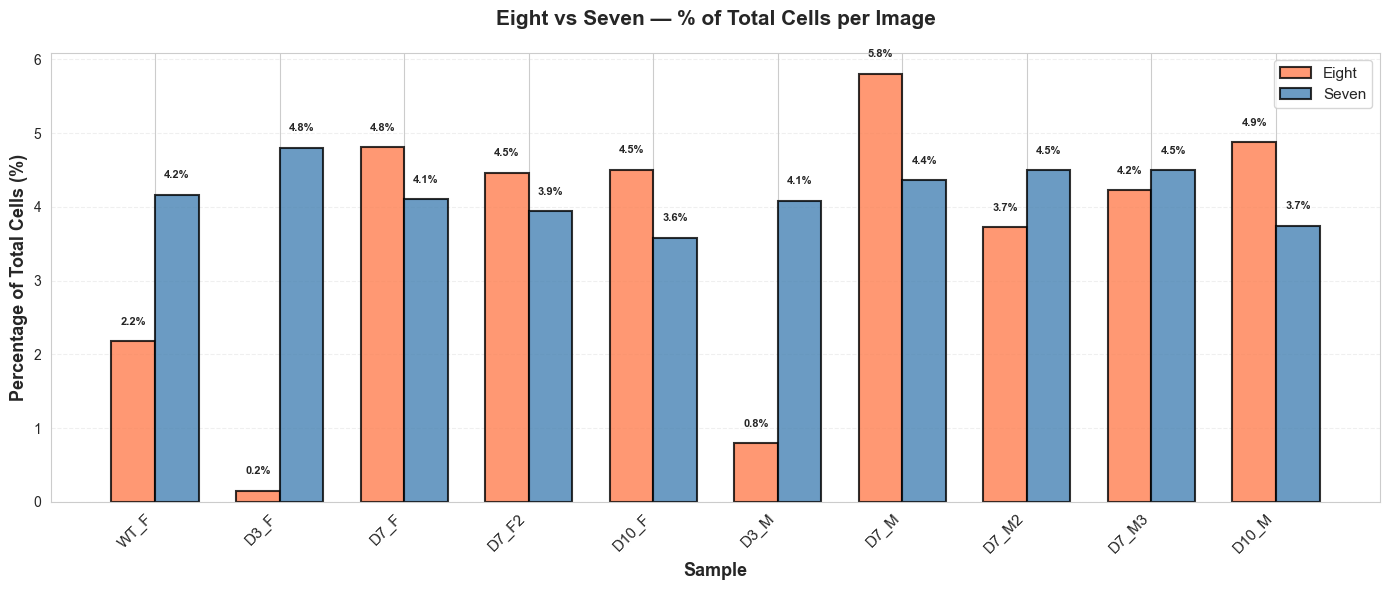


Statistics for Eight+ as % of total cells:
  Mean: 3.55%
  Std:  1.88%
  Min:  0.15%
  Max:  5.80%

  Detailed breakdown:
    WT_F: 161 Eight+ / 7396 total = 2.18%
    D3_F: 12 Eight+ / 7922 total = 0.15%
    D7_F: 510 Eight+ / 10606 total = 4.81%
    D7_F2: 495 Eight+ / 11091 total = 4.46%
    D10_F: 395 Eight+ / 8774 total = 4.50%
    D3_M: 66 Eight+ / 8308 total = 0.79%
    D7_M: 842 Eight+ / 14517 total = 5.80%
    D7_M2: 501 Eight+ / 13460 total = 3.72%
    D7_M3: 451 Eight+ / 10677 total = 4.22%
    D10_M: 512 Eight+ / 10505 total = 4.87%

Statistics for Seven+ as % of total cells:
  Mean: 4.18%
  Std:  0.37%
  Min:  3.58%
  Max:  4.80%

  Detailed breakdown:
    WT_F: 308 Seven+ / 7396 total = 4.16%
    D3_F: 380 Seven+ / 7922 total = 4.80%
    D7_F: 435 Seven+ / 10606 total = 4.10%
    D7_F2: 437 Seven+ / 11091 total = 3.94%
    D10_F: 314 Seven+ / 8774 total = 3.58%
    D3_M: 339 Seven+ / 8308 total = 4.08%
    D7_M: 633 Seven+ / 14517 total = 4.36%
    D7_M2: 605 Seven+ / 13

In [44]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

def plot_total_cd45_percentage(counts_dfs, fov_total_cells_renamed, cell_classes):
    """
    Bar plot comparing two cell classes (from optionally different DataFrames) as % of total cells per image.
    
    Args:
        counts_dfs: Either a single DataFrame (used for both classes) or a list of two DataFrames
        fov_total_cells_renamed: Dictionary mapping fov_name -> total_cell_count
        cell_classes: List of two cell class strings to compare (e.g. ['CD45', 'Treg'])
    
    Returns:
        List of two DataFrames with totals and percentages for each class
    """
    # Handle single or dual dataframe input
    if isinstance(counts_dfs, list):
        df1, df2 = counts_dfs[0], counts_dfs[1]
    else:
        df1 = df2 = counts_dfs

    class1, class2 = cell_classes[0], cell_classes[1]
    colors = ['coral', 'steelblue']

    fov_order = ['WT_F', 'D3_F', 'D7_F', 'D7_F2', 'D10_F', 'D3_M', 'D7_M', 'D7_M2', 'D7_M3', 'D10_M']

    results = []
    for df, cell_class in zip([df1, df2], cell_classes):
        data = df[df['class'] == cell_class].copy()
        totals = data.groupby('fov')['count'].sum().reset_index()
        totals.columns = ['fov', 'cd45_count']
        totals['total_cells'] = totals['fov'].map(fov_total_cells_renamed)
        totals['percentage'] = (totals['cd45_count'] / totals['total_cells']) * 100

        order = [fov for fov in fov_order if fov in totals['fov'].values]
        totals['fov'] = pd.Categorical(totals['fov'], categories=order, ordered=True)
        totals = totals.sort_values('fov')
        results.append(totals)

    totals1, totals2 = results

    # Plot
    fovs = totals1['fov'].astype(str).tolist()
    x = range(len(fovs))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))

    bars1 = ax.bar([i - bar_width/2 for i in x], totals1['percentage'],
                   width=bar_width, color=colors[0], edgecolor='black', alpha=0.8,
                   linewidth=1.5, label=class1)
    bars2 = ax.bar([i + bar_width/2 for i in x], totals2['percentage'],
                   width=bar_width, color=colors[1], edgecolor='black', alpha=0.8,
                   linewidth=1.5, label=class2)

    # Add percentage labels
    for i, (_, row) in enumerate(totals1.iterrows()):
        ax.text(i - bar_width/2, row['percentage'] + 0.2, f"{row['percentage']:.1f}%",
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    for i, (_, row) in enumerate(totals2.iterrows()):
        ax.text(i + bar_width/2, row['percentage'] + 0.2, f"{row['percentage']:.1f}%",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xlabel('Sample', fontsize=13, fontweight='bold')
    ax.set_ylabel('Percentage of Total Cells (%)', fontsize=13, fontweight='bold')
    ax.set_title(f'{class1} vs {class2} — % of Total Cells per Image', 
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_xticks(list(x))
    ax.set_xticklabels(fovs, rotation=45, ha='right', fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()

    # Print statistics
    for totals, cell_class in zip([totals1, totals2], cell_classes):
        print(f"\nStatistics for {cell_class}+ as % of total cells:")
        print(f"  Mean: {totals['percentage'].mean():.2f}%")
        print(f"  Std:  {totals['percentage'].std():.2f}%")
        print(f"  Min:  {totals['percentage'].min():.2f}%")
        print(f"  Max:  {totals['percentage'].max():.2f}%")
        print(f"\n  Detailed breakdown:")
        for _, row in totals.iterrows():
            print(f"    {row['fov']}: {row['cd45_count']} {cell_class}+ / {row['total_cells']} total = {row['percentage']:.2f}%")

    return results

#### USAGE
# Same dataframe, two classes:
results = plot_total_cd45_percentage(counts_df, fov_total_cells_renamed, cell_classes=['Eight', 'Seven'])

# Different dataframes, two classes:
#results = plot_total_cd45_percentage([counts_df, doubleZ_bs_df], fov_total_cells_renamed, cell_classes=['Macrophage', 'Seven'])

In [ ]:
def plot_cd45_compartment_distribution(counts_df, cluster_name, cell_class='CD45', 
                                       compartments=['Epidermis', 'Dermis', 'BloodVessels']):
    """
    Grouped bar plot showing CD45 distribution across compartments.
    Each image has N bars (one per compartment) showing:
        CD45_in_compartment / Total_CD45_across_all_compartments_in_image
    
    Args:
        counts_df: DataFrame with columns [fov, compartment, class, count]
        cell_class: Cell class to plot (default 'CD45')
        compartments: List of compartments to include in plot (any number)
    
    Returns:
        DataFrame with pivot table of percentages
    """
    # Filter for the target cell class only
    cd45_data = counts_df[counts_df['class'] == cell_class].copy()
    
    # Denominator: total CD45 cells per FOV across ALL compartments (not just selected ones)
    total_cd45_per_fov = cd45_data.groupby('fov')['count'].sum()
    cd45_data['total_cd45_in_fov'] = cd45_data['fov'].map(total_cd45_per_fov)
    
    # Calculate percentage of total CD45 cells
    cd45_data['percentage_of_cd45'] = (cd45_data['count'] / cd45_data['total_cd45_in_fov']) * 100
    
    # Filter to only the compartments we want to plot
    cd45_data = cd45_data[cd45_data['compartment'].isin(compartments)]
    
    # Define custom order for FOVs
    fov_order = ['WT_F', 'D3_F', 'D7_F', 'D7_F2', 'D10_F', 'WT_M', 'D3_M', 'D7_M', 'D7_M2', 'D7_M3', 'D10_M']
    fov_order = [fov for fov in fov_order if fov in cd45_data['fov'].values]
    
    # Pivot data for grouped bar plot
    pivot_data = cd45_data.pivot_table(
        index='fov', 
        columns='compartment', 
        values='percentage_of_cd45', 
        fill_value=0
    )
    pivot_data = pivot_data.reindex(fov_order)
    pivot_data = pivot_data.reindex(columns=compartments, fill_value=0)
    
    # --- Dynamic bar layout ---
    n_compartments = len(compartments)
    fig, ax = plt.subplots(figsize=(max(20, n_compartments * 5), 9))
    
    x = np.arange(len(pivot_data.index))
    width = 0.9 / n_compartments  # Total group width = 0.8, split across compartments
    
    # Generate colors dynamically if more compartments than predefined colors
    predefined_colors = {
        'Epidermis':    '#FF6B6B',
        'Dermis':       '#4ECDC4',
        'BloodVessels': '#95E1D3'
    }
    cmap = plt.cm.get_cmap('tab10', n_compartments)
    colors = {c: predefined_colors.get(c, cmap(i)) for i, c in enumerate(compartments)}
    
    # Create bars for each compartment
    for i, compartment in enumerate(compartments):
        offset = width * (i - (n_compartments - 1) / 2)  # Centre the group around each x tick
        bars = ax.bar(x + offset, pivot_data[compartment], width,
                      label=compartment, color=colors[compartment],
                      edgecolor='black', alpha=0.85, linewidth=1.2)
        
        # Add value labels on bars
        for j, value in enumerate(pivot_data[compartment]):
            if value > 0:
                ax.text(x[j] + offset, value + 0.2, f'{value:.1f}%',
                        ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Customize plot
    ax.set_xlabel('Sample', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'% of Total {cluster_name} Cells', fontsize=13, fontweight='bold')
    ax.set_title(f'{cluster_name} Cell Distribution Across Compartments\n'
                 f'({cluster_name} in compartment / Total {cluster_name} in image)',
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_data.index, rotation=45, ha='right', fontsize=11)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=11, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{cluster_name}+ Distribution Across Compartments (as % of total {cluster_name}):")
    print("=" * 80)
    print(pivot_data.to_string())
    
    print(f"\nMean distribution across all samples:")
    for compartment in compartments:
        mean_pct = pivot_data[compartment].mean()
        std_pct  = pivot_data[compartment].std()
        print(f"  {compartment}: {mean_pct:.2f}% ± {std_pct:.2f}%")
    
    return pivot_data


PLOT 2: Cluster Seven: Distribution Across Compartments


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_14220\1896893794.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_compartments)


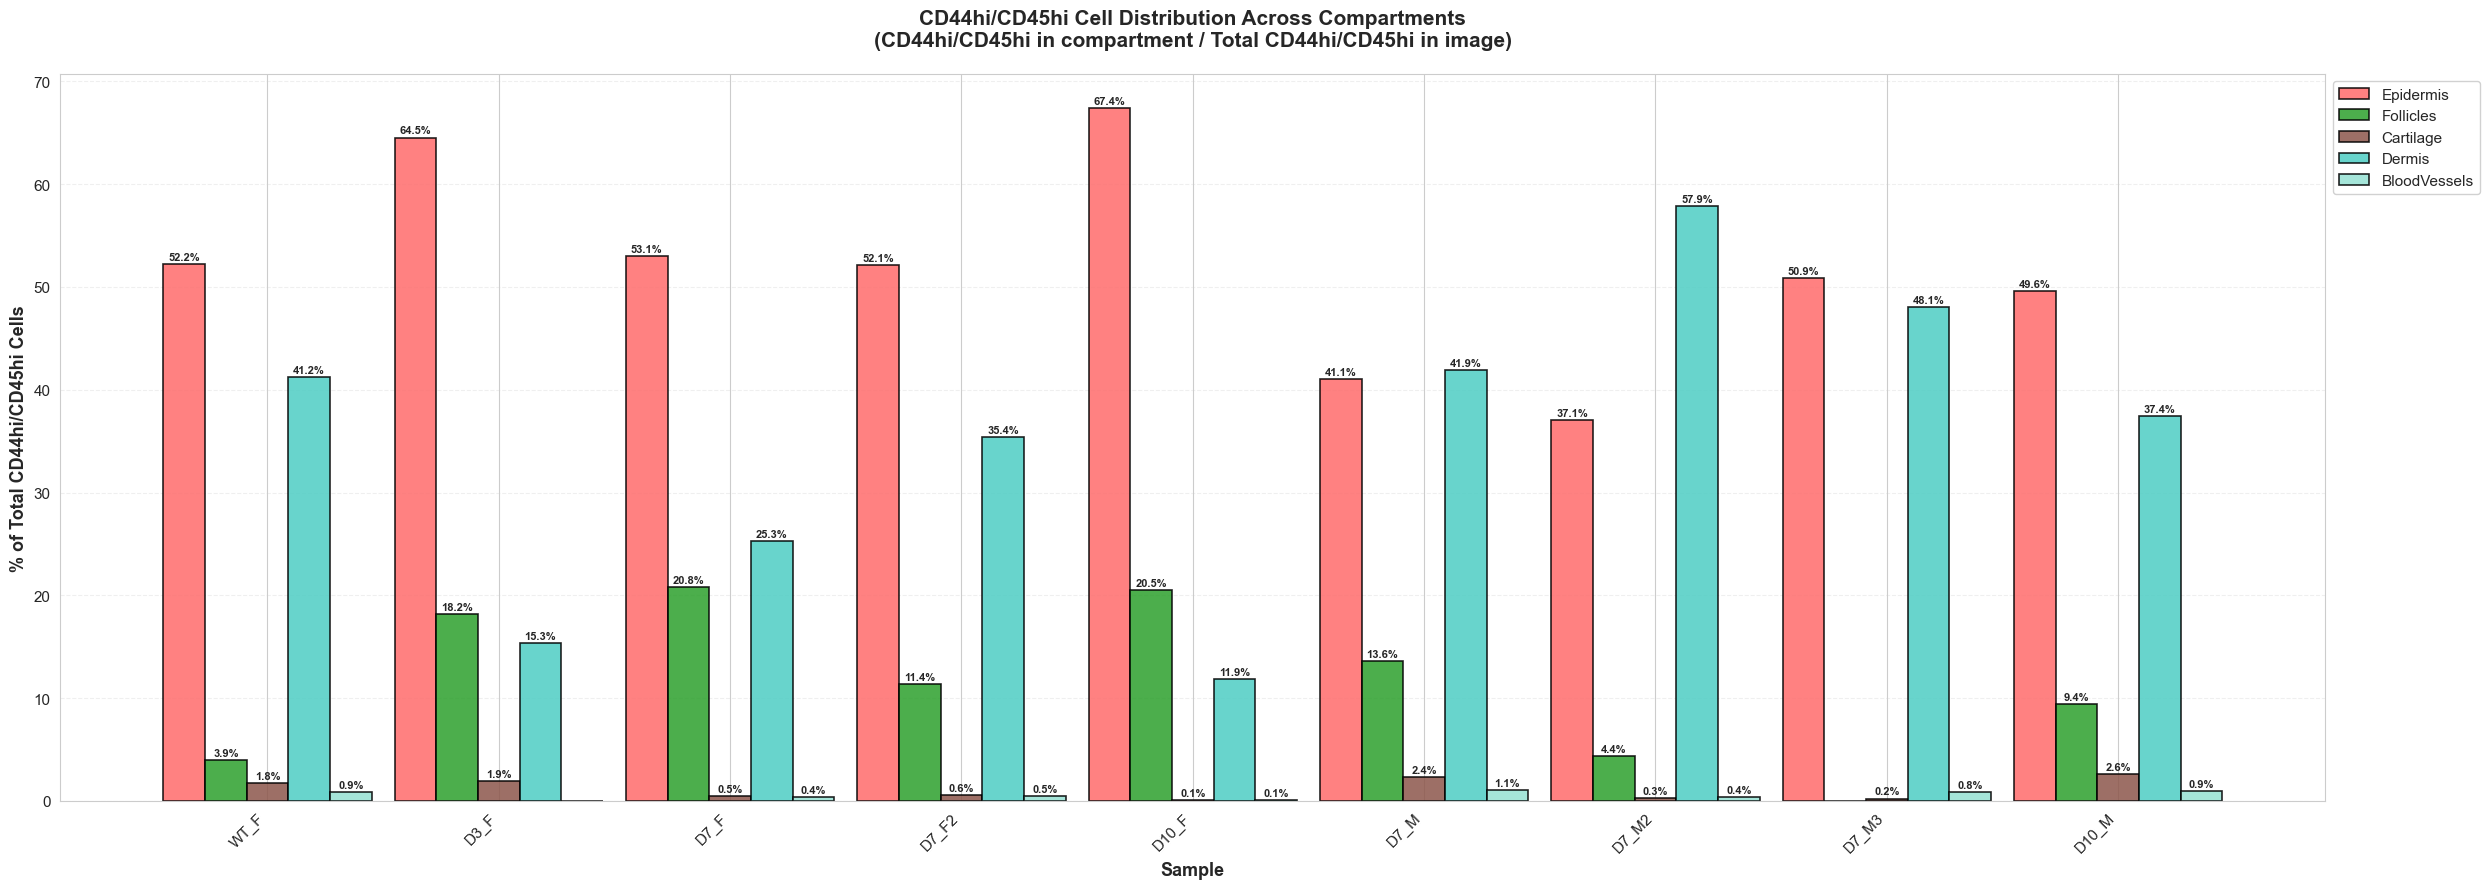


CD44hi/CD45hi+ Distribution Across Compartments (as % of total CD44hi/CD45hi):
compartment  Epidermis  Follicles  Cartilage     Dermis  BloodVessels
fov                                                                  
WT_F         52.192982   3.947368   1.754386  41.228070      0.877193
D3_F         64.536741  18.210863   1.916933  15.335463      0.000000
D7_F         53.051643  20.845070   0.469484  25.258216      0.375587
D7_F2        52.148664  11.382114   0.580720  35.423926      0.464576
D10_F        67.369589  20.532741   0.110988  11.875694      0.110988
D7_M         41.071429  13.602941   2.363445  41.911765      1.050420
D7_M2        37.069548   4.388926   0.270088  57.866307      0.405132
D7_M3        50.874525   0.000000   0.228137  48.060837      0.836502
D10_M        49.631191   9.378293   2.634352  37.407798      0.948367

Mean distribution across all samples:
  Epidermis: 51.99% ± 9.64%
  Follicles: 11.37% ± 7.60%
  Cartilage: 1.15% ± 1.01%
  Dermis: 34.93% ± 15.01%
  

In [95]:
print("\n" + "="*80)
print("PLOT 2: Cluster Seven: Distribution Across Compartments")
print("="*80)

cd45_compartment_dist = plot_cd45_compartment_distribution(
    counts_df, 
    cell_class='2', cluster_name = 'CD44hi/CD45hi',
    compartments=['Epidermis', 'Follicles', 'Cartilage', 'Dermis', 'BloodVessels']
)


PLOT 2: 'Absolute' CD45 Distribution Across Compartments


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_14220\540020222.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_compartments)


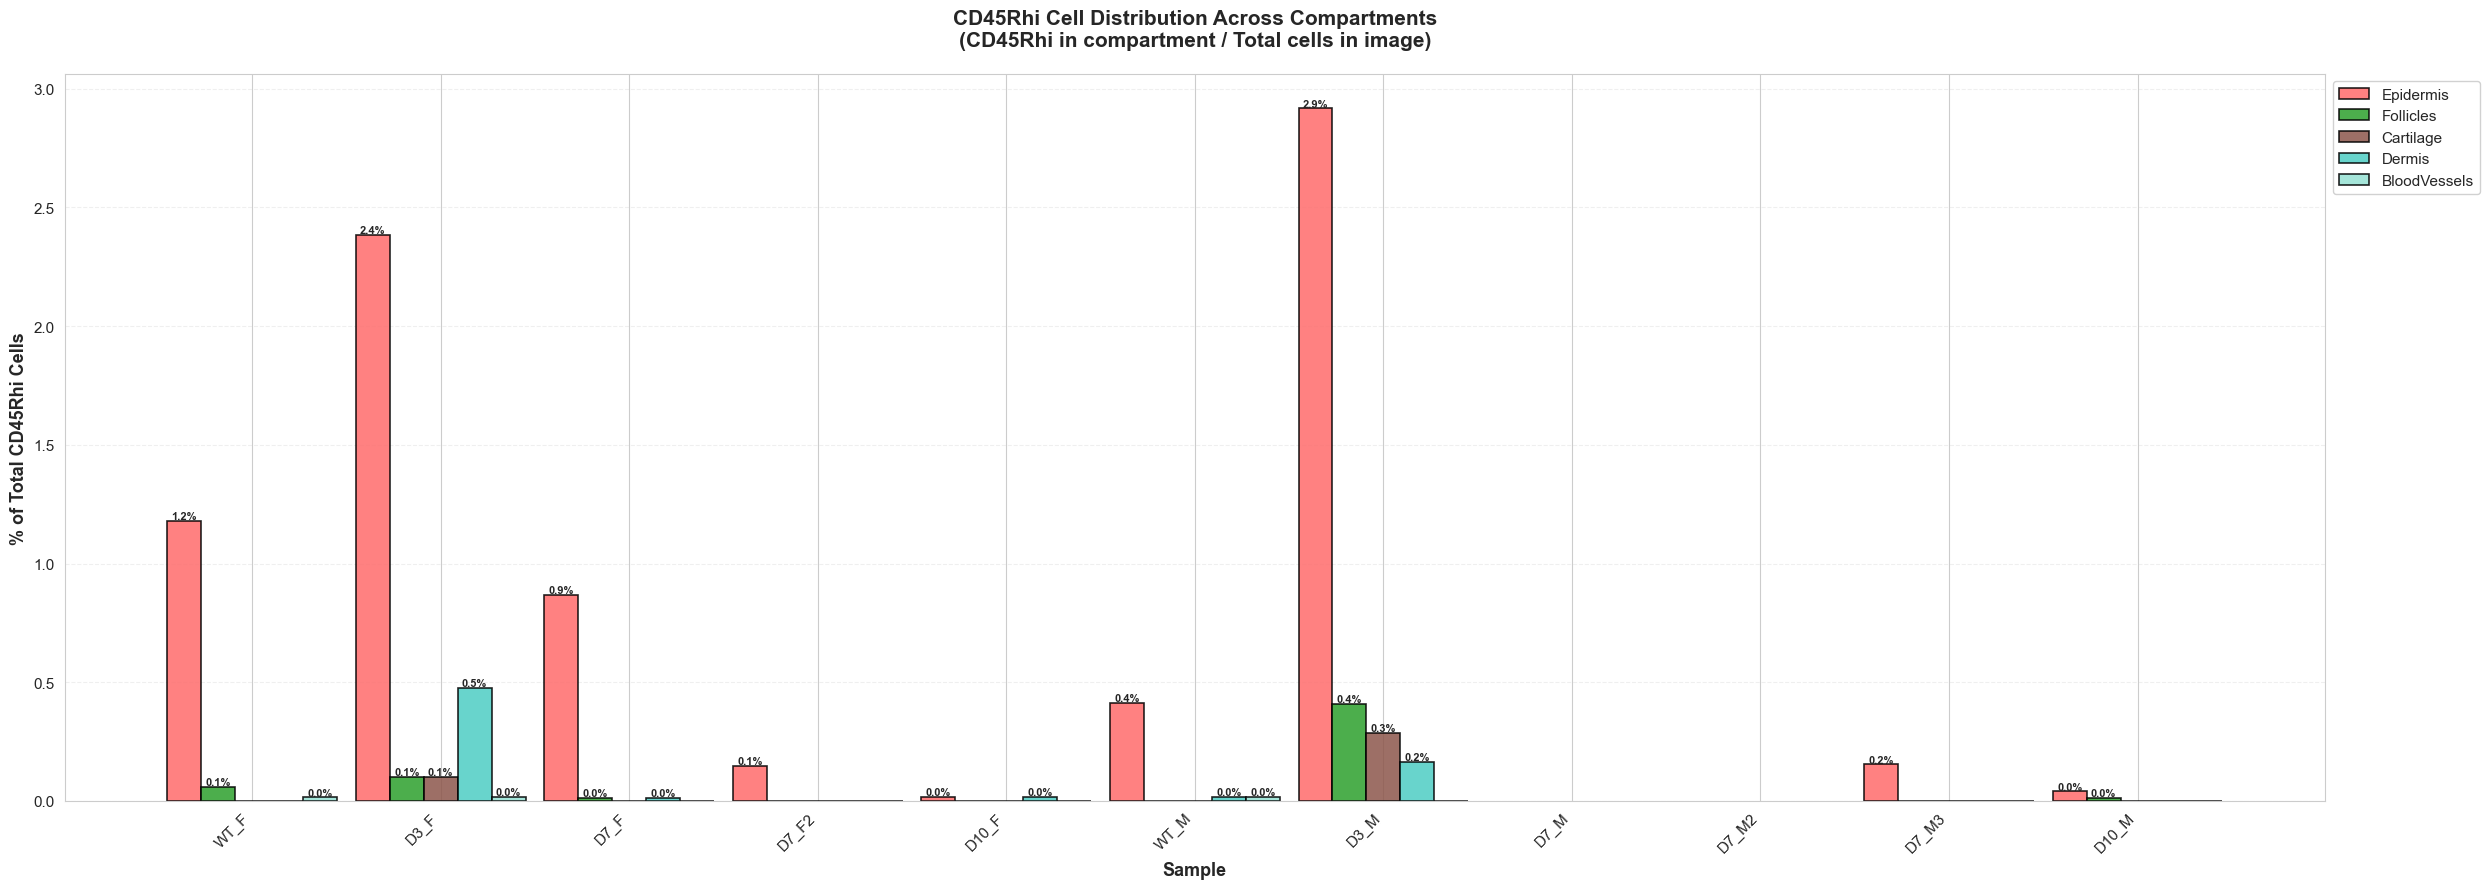


9+ Distribution Across Compartments (as % of total 9):
compartment  Epidermis  Follicles  Cartilage    Dermis  BloodVessels
fov                                                                 
WT_F          1.178929   0.059693   0.000000  0.000000      0.014923
D3_F          2.385009   0.102215   0.102215  0.477002      0.017036
D7_F          0.867499   0.011884   0.000000  0.011884      0.000000
D7_F2         0.147744   0.000000   0.000000  0.000000      0.000000
D10_F         0.016779   0.000000   0.000000  0.016779      0.000000
WT_M          0.411596   0.000000   0.000000  0.017895      0.017895
D3_M          2.917177   0.407997   0.285598  0.163199      0.000000
D7_M               NaN        NaN        NaN       NaN           NaN
D7_M2              NaN        NaN        NaN       NaN           NaN
D7_M3         0.153955   0.000000   0.000000  0.000000      0.000000
D10_M         0.040382   0.013461   0.000000  0.000000      0.000000

Mean distribution across all samples:
  Epider

In [130]:
def plot_cd45_compartment_distribution(counts_df, cluster_name, cell_class='CD45', 
                                       compartments=['Epidermis', 'Dermis', 'BloodVessels']):
    """
    Grouped bar plot showing CD45 distribution across compartments.
    Each image has N bars (one per compartment) showing:
        CD45_in_compartment / Total_CD45_across_all_compartments_in_image
    
    Args:
        counts_df: DataFrame with columns [fov, compartment, class, count]
        cell_class: Cell class to plot (default 'CD45')
        compartments: List of compartments to include in plot (any number)
    
    Returns:
        DataFrame with pivot table of percentages
    """
    # Filter for the target cell class only
    cd45_data = counts_df[counts_df['class'] == cell_class].copy()
    
    # Denominator: total cells per FOV across ALL classes and compartments
    total_cells_per_fov = counts_df.groupby('fov')['count'].sum()
    cd45_data['total_cells_in_fov'] = cd45_data['fov'].map(total_cells_per_fov)

    # Calculate percentage of total cells
    cd45_data['percentage_of_cd45'] = (cd45_data['count'] / cd45_data['total_cells_in_fov']) * 100
    
    # Filter to only the compartments we want to plot
    cd45_data = cd45_data[cd45_data['compartment'].isin(compartments)]
    
    # Define custom order for FOVs
    fov_order = ['WT_F', 'D3_F', 'D7_F', 'D7_F2', 'D10_F', 'WT_M', 'D3_M', 'D7_M', 'D7_M2', 'D7_M3', 'D10_M']
    fov_order = [fov for fov in fov_order if fov in counts_df['fov'].values]
    
    # Pivot data for grouped bar plot
    pivot_data = cd45_data.pivot_table(
        index='fov', 
        columns='compartment', 
        values='percentage_of_cd45', 
        fill_value=0
    )
    pivot_data = pivot_data.reindex(fov_order)
    pivot_data = pivot_data.reindex(columns=compartments, fill_value=0)
    
    # --- Dynamic bar layout ---
    n_compartments = len(compartments)
    fig, ax = plt.subplots(figsize=(max(20, n_compartments * 5), 9))
    
    x = np.arange(len(pivot_data.index))
    width = 0.9 / n_compartments  # Total group width = 0.8, split across compartments
    
    # Generate colors dynamically if more compartments than predefined colors
    predefined_colors = {
        'Epidermis':    '#FF6B6B',
        'Dermis':       '#4ECDC4',
        'BloodVessels': '#95E1D3'
    }
    cmap = plt.cm.get_cmap('tab10', n_compartments)
    colors = {c: predefined_colors.get(c, cmap(i)) for i, c in enumerate(compartments)}
    
    # Create bars for each compartment
    for i, compartment in enumerate(compartments):
        offset = width * (i - (n_compartments - 1) / 2)  # Centre the group around each x tick
        bars = ax.bar(x + offset, pivot_data[compartment], width,
                      label=compartment, color=colors[compartment],
                      edgecolor='black', alpha=0.85, linewidth=1.2)
        
        # Add value labels on bars
        for j, value in enumerate(pivot_data[compartment]):
            if value > 0:
                ax.text(x[j] + offset, value - 0.001, f'{value:.1f}%',
                        ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Customize plot
    ax.set_xlabel('Sample', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'% of Total {cluster_name} Cells', fontsize=13, fontweight='bold')
    ax.set_title(f'{cluster_name} Cell Distribution Across Compartments\n'
             f'({cluster_name} in compartment / Total cells in image)',
             fontsize=15, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_data.index, rotation=45, ha='right', fontsize=11)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=11, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{cell_class}+ Distribution Across Compartments (as % of total {cell_class}):")
    print("=" * 80)
    print(pivot_data.to_string())
    
    print(f"\nMean distribution across all samples:")
    for compartment in compartments:
        mean_pct = pivot_data[compartment].mean()
        std_pct  = pivot_data[compartment].std()
        print(f"  {compartment}: {mean_pct:.2f}% ± {std_pct:.2f}%")
    
    return pivot_data

#usage
print("\n" + "="*80)
print("PLOT 2: 'Absolute' CD45 Distribution Across Compartments")
print("="*80)

cd45_compartment_dist = plot_cd45_compartment_distribution(
    counts_df, 
    cell_class='9',
    cluster_name = 'CD45Rhi',
    compartments=['Epidermis', 'Follicles', 'Cartilage', 'Dermis', 'BloodVessels']
)

In [57]:
# Updated function with ANOVA analysis
def plot_cd45_compartment_distribution_with_stats(counts_df, cell_class='CD45', 
                                                   compartments=['Epidermis', 'Dermis', 'BloodVessels']):
    """
    Grouped bar plot showing CD45 distribution across compartments WITH ANOVA statistics.
    Each image has 3 bars (one per compartment) showing CD45_compartment / Total_CD45.
    
    Args:
        counts_df: DataFrame with columns [fov, compartment, class, count]
        cell_class: Cell class to plot (default 'CD45')
        compartments: List of compartments to include in plot
    
    Returns:
        Dictionary with pivot table and statistical results
    """
    from scipy.stats import f_oneway
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    
    # Filter for CD45 only
    cd45_data = counts_df[counts_df['class'] == cell_class].copy()
    
    # Calculate total CD45 per FOV (across all compartments)
    total_cd45_per_fov = cd45_data.groupby('fov')['count'].sum().to_dict()
    
    # Add total CD45 column
    cd45_data['total_cd45_in_fov'] = cd45_data['fov'].map(total_cd45_per_fov)
    
    # Calculate percentage of total CD45
    cd45_data['percentage_of_cd45'] = (cd45_data['count'] / cd45_data['total_cd45_in_fov']) * 100
    
    # Filter to only the compartments we want to plot
    cd45_data = cd45_data[cd45_data['compartment'].isin(compartments)]
    
    # Add grouping variable for statistics
    def get_group(fov_name):
        if 'WT' in fov_name:
            return 'WT'
        elif 'D3' in fov_name:
            return 'D3'
        elif 'D7' in fov_name:
            return 'D7'
        elif 'D10' in fov_name:
            return 'D10'
        else:
            return 'Other'
    
    cd45_data['group'] = cd45_data['fov'].apply(get_group)
    
    # ========================================================================
    # STATISTICAL ANALYSIS - Perform ANOVA for each compartment
    # ========================================================================
    print("="*80)
    print("STATISTICAL ANALYSIS - ANOVA by Compartment")
    print("="*80)
    
    stats_results = {}
    
    for compartment in compartments:
        print(f"\n{'='*80}")
        print(f"{compartment}")
        print('='*80)
        
        comp_data = cd45_data[cd45_data['compartment'] == compartment]
        
        # Prepare data for ANOVA
        groups = comp_data['group'].unique()
        group_data = [comp_data[comp_data['group'] == group]['percentage_of_cd45'].values 
                      for group in groups]
        
        # Perform one-way ANOVA
        f_stat, p_value = f_oneway(*group_data)
        
        print(f"One-way ANOVA:")
        print(f"  F-statistic: {f_stat:.4f}")
        print(f"  p-value: {p_value:.4f}")
        
        if p_value < 0.05:
            print(f"  Result: SIGNIFICANT difference between groups (p < 0.05)")
        else:
            print(f"  Result: NO significant difference between groups (p >= 0.05)")
        
        # Perform Tukey's HSD post-hoc test
        print(f"\nTukey's HSD Post-hoc Test:")
        tukey_result = pairwise_tukeyhsd(comp_data['percentage_of_cd45'], comp_data['group'], alpha=0.05)
        print(tukey_result)
        
        # Extract significant pairs
        tukey_df = pd.DataFrame(data=tukey_result.summary().data[1:], 
                               columns=tukey_result.summary().data[0])
        tukey_df['reject'] = tukey_df['reject'].astype(bool)
        significant_pairs = tukey_df[tukey_df['reject'] == True]
        
        print(f"\nSignificant pairwise comparisons (p < 0.05):")
        if len(significant_pairs) > 0:
            for idx, row in significant_pairs.iterrows():
                print(f"  {row['group1']} vs {row['group2']}: p = {row['p-adj']:.4f}")
        else:
            print("  None")
        
        # Store results
        stats_results[compartment] = {
            'anova_f': f_stat,
            'anova_p': p_value,
            'tukey_result': tukey_result,
            'tukey_df': tukey_df,
            'significant_pairs': significant_pairs
        }
    
    # ========================================================================
    # CREATE VISUALIZATION
    # ========================================================================
    
    # Define custom order for FOVs
    fov_order = ['WT_F', 'D3_F', 'D7_F', 'D7_F2', 'D10_F', 'D3_M', 'D7_M', 'D7_M2', 'D7_M3', 'D10_M']
    fov_order = [fov for fov in fov_order if fov in cd45_data['fov'].values]
    
    # Pivot data for grouped bar plot
    pivot_data = cd45_data.pivot_table(
        index='fov', 
        columns='compartment', 
        values='percentage_of_cd45', 
        fill_value=0
    )
    
    # Reindex to match fov_order
    pivot_data = pivot_data.reindex(fov_order)
    
    # Ensure compartments are in the desired order
    pivot_data = pivot_data[compartments]
    
    # Create grouped bar plot
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Set width and positions
    x = np.arange(len(pivot_data.index))
    width = 0.25
    
    # Define colors for each compartment
    colors = {
        'Epidermis': '#FF6B6B',      # Red
        'Dermis': '#4ECDC4',          # Teal
        'BloodVessels': '#95E1D3'    # Light green
    }
    
    # Create bars for each compartment
    for i, compartment in enumerate(compartments):
        offset = width * (i - 1)  # Center the groups
        
        # Add asterisks to label if significant ANOVA
        label_text = compartment
        if stats_results[compartment]['anova_p'] < 0.001:
            label_text += " ***"
        elif stats_results[compartment]['anova_p'] < 0.01:
            label_text += " **"
        elif stats_results[compartment]['anova_p'] < 0.05:
            label_text += " *"
        
        bars = ax.bar(x + offset, pivot_data[compartment], width, 
                     label=label_text, color=colors[compartment], 
                     edgecolor='black', alpha=0.85, linewidth=1.2)
        
        # Add value labels on bars
        for j, (idx, value) in enumerate(pivot_data[compartment].items()):
            if value > 0:  # Only show label if there's a value
                ax.text(j + offset, value + 0.2, f'{value:.1f}%', 
                       ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Customize plot
    ax.set_xlabel('Sample', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'Percentage of Total {cell_class}+ Cells (%)', fontsize=13, fontweight='bold')
    ax.set_title(f'{cell_class}+ Cell Distribution Across Compartments\n({cell_class} in compartment / Total {cell_class} in image)\n* = p<0.05, ** = p<0.01, *** = p<0.001 (ANOVA)', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_data.index, rotation=45, ha='right', fontsize=11)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9, title='Compartment (ANOVA)')
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print(f"{cell_class}+ Distribution Across Compartments (as % of total {cell_class}):")
    print("="*80)
    print(pivot_data.to_string())
    
    print(f"\nMean distribution across all samples:")
    for compartment in compartments:
        mean_pct = pivot_data[compartment].mean()
        std_pct = pivot_data[compartment].std()
        p_val = stats_results[compartment]['anova_p']
        p_text = f"p = {p_val:.4f}" if p_val >= 0.001 else "p < 0.001"
        print(f"  {compartment}: {mean_pct:.2f}% ± {std_pct:.2f}% (ANOVA {p_text})")
    
    return {
        'pivot_data': pivot_data,
        'stats_results': stats_results,
        'cd45_data': cd45_data
    }


# Execute the function with statistics
print("\n" + "="*80)
print("PLOT 2: CD45 Distribution Across Compartments (with ANOVA)")
print("="*80)

results = plot_cd45_compartment_distribution_with_stats(
    counts_df, 
    cell_class='CD45',
    compartments=['Epidermis', 'Dermis', 'BloodVessels']
)

# Access the results
cd45_compartment_dist = results['pivot_data']
compartment_stats = results['stats_results']


PLOT 2: CD45 Distribution Across Compartments (with ANOVA)
STATISTICAL ANALYSIS - ANOVA by Compartment

Epidermis


TypeError: At least two samples are required; got 0.

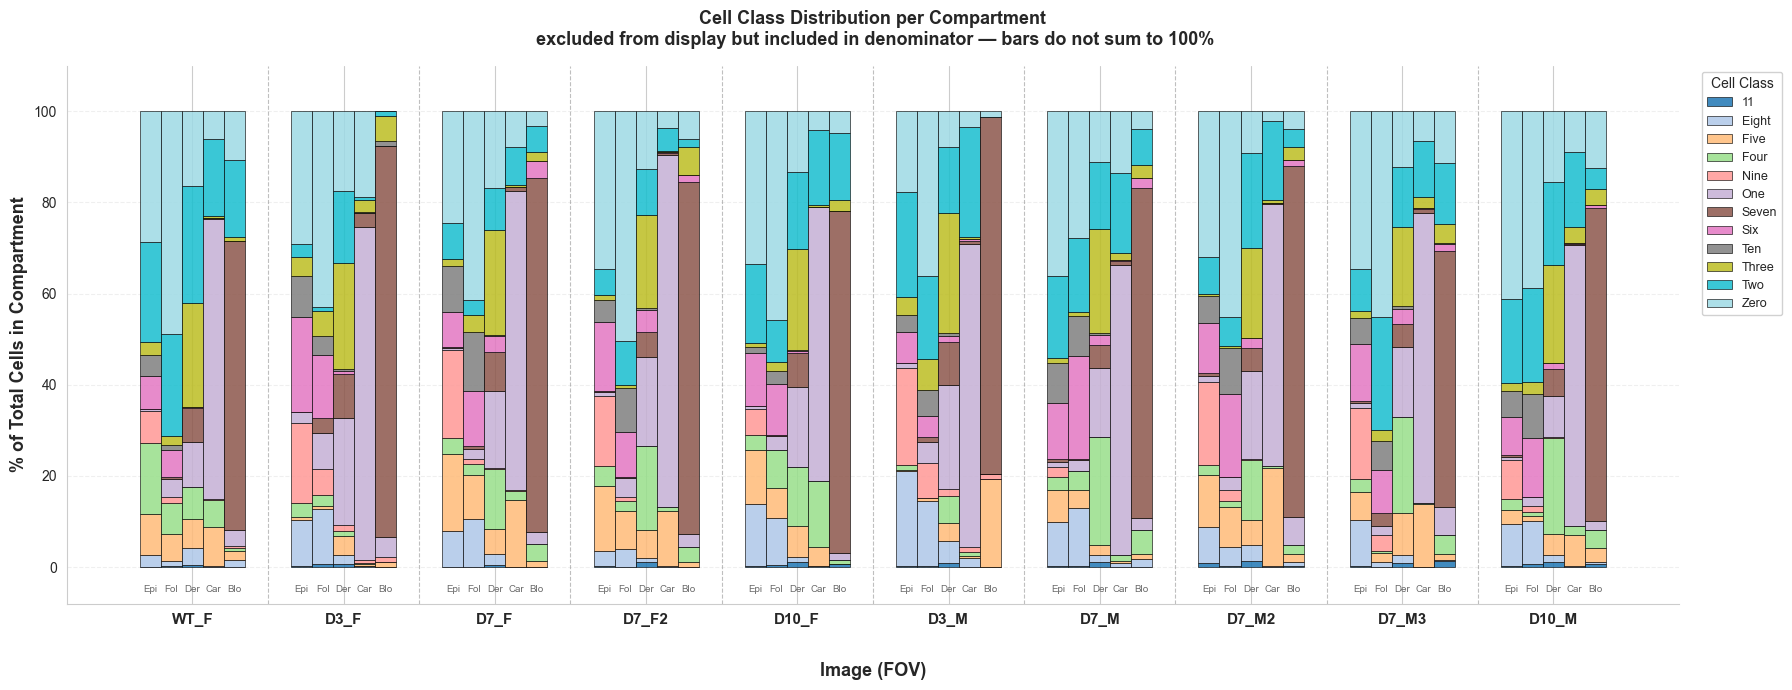

class                     11      Eight       Five       Four       Nine        One      Seven        Six        Ten      Three        Two       Zero
fov   compartment                                                                                                                                    
D10_F BloodVessels  0.781250   0.000000   0.000000   0.781250   0.000000   1.562500  75.000000   0.000000   0.000000   2.343750  14.843750   4.687500
      Cartilage     0.152905   0.000000   4.204893  14.525994   0.000000  60.015291   0.152905   0.000000   0.000000   0.305810  16.590214   4.051988
      Dermis        1.026830   1.126201   6.856575  12.984432   0.066247  17.489235   7.386552   0.496853   0.264988  22.126532  16.859887  13.315667
      Epidermis     0.246685  13.567684  11.902559   3.299414   5.673759   0.616713   0.030836  11.686710   1.202590   0.925069  17.237126  33.610854
      Follicles     0.496894  10.186335   6.583851   8.322981   0.124224   3.105590   0.124224  11.1

In [47]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd


def plot_stacked_cell_class_by_compartment(
        counts_df,
        compartments=['Epidermis', 'Dermis', 'BloodVessels'],
        exclude_classes=['Epithelial', 'Chondrocyte'],
        scale_to_plotted=False):

    fov_order = ['WT_F', 'D3_F', 'D7_F', 'D7_F2', 'D10_F', 'D3_M', 'D7_M', 'D7_M2', 'D7_M3', 'D10_M']
    fov_order = [f for f in fov_order if f in counts_df['fov'].values]

    # Filter to relevant compartments
    data = counts_df[counts_df['compartment'].isin(compartments)].copy()

    # Calculate totals BEFORE excluding classes
    compartment_totals = (
        data.groupby(['fov', 'compartment'])['count']
        .sum().reset_index()
        .rename(columns={'count': 'compartment_total'})
    )
    data = data.merge(compartment_totals, on=['fov', 'compartment'])
    data['percentage'] = (data['count'] / data['compartment_total']) * 100

    # Exclude unwanted classes
    data = data[~data['class'].isin(exclude_classes)]

    # Optionally rescale
    if scale_to_plotted:
        plotted_totals = (
            data.groupby(['fov', 'compartment'])['count']
            .sum().reset_index()
            .rename(columns={'count': 'plotted_total'})
        )
        data = data.merge(plotted_totals, on=['fov', 'compartment'])
        data['percentage'] = (data['count'] / data['plotted_total']) * 100

    # Build pivot table
    cell_classes   = sorted(data['class'].unique())
    n_classes      = len(cell_classes)
    n_fovs         = len(fov_order)
    n_compartments = len(compartments)

    pivot = data.pivot_table(
        index=['fov', 'compartment'],
        columns='class',
        values='percentage',
        fill_value=0
    )[cell_classes]

    # Colours
    cmap         = plt.get_cmap('tab20', n_classes)
    class_colors = {cls: cmap(i) for i, cls in enumerate(cell_classes)}

    # Bar positions
    bar_width     = 0.25
    group_spacing = 1.8
    fov_centres   = np.arange(n_fovs) * group_spacing
    offsets       = np.linspace(
        -(n_compartments - 1) * bar_width / 2,
         (n_compartments - 1) * bar_width / 2,
        n_compartments
    )

    # Draw stacked bars — pass label= only on the FIRST fov/compartment
    # so each class gets exactly one legend entry
    fig, ax = plt.subplots(figsize=(max(16, n_fovs * 1.8), 7))

    for fov_idx, fov in enumerate(fov_order):
        for comp_idx, compartment in enumerate(compartments):
            x = fov_centres[fov_idx] + offsets[comp_idx]

            try:
                row = pivot.loc[(fov, compartment)]
            except KeyError:
                row = pd.Series(0, index=cell_classes)

            bottom = 0
            for cls in cell_classes:
                value = row[cls]
                # Only add a label on the very first bar drawn for each class
                # so the legend gets exactly one entry per class
                label = cls if (fov_idx == 0 and comp_idx == 0) else '_nolegend_'
                ax.bar(
                    x, value, bar_width,
                    bottom=bottom,
                    color=class_colors[cls],
                    edgecolor='black',
                    linewidth=0.5,
                    alpha=0.85,
                    label=label
                )
                bottom += value

    # Compartment sub-labels below each bar
    comp_abbrev = {c: c[:3] for c in compartments}
    for fov_idx in range(n_fovs):
        for comp_idx, compartment in enumerate(compartments):
            x = fov_centres[fov_idx] + offsets[comp_idx]
            ax.text(x, -4, comp_abbrev[compartment],
                    ha='center', va='top', fontsize=7, color='dimgray')

    # Axes
    ax.set_xticks(fov_centres)
    ax.set_xticklabels(fov_order, fontsize=11, fontweight='bold')
    ax.set_xlabel('Image (FOV)', fontsize=13, fontweight='bold', labelpad=25)

    if scale_to_plotted:
        ylabel     = '% of Plotted Cells in Compartment'
        title_note = (f'Scaled to plotted classes only\n'
                      f'({", ".join(exclude_classes)} excluded from display and denominator)')
    else:
        ylabel     = '% of Total Cells in Compartment'
        title_note = (f'{", ".join(exclude_classes)} excluded from display '
                      f'but included in denominator — bars do not sum to 100%')

    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_title(
        f'Cell Class Distribution per Compartment\n{title_note}',
        fontsize=13, fontweight='bold', pad=15
    )

    # Vertical dividers between FOV groups
    for i in range(n_fovs - 1):
        ax.axvline(
            x=(fov_centres[i] + fov_centres[i + 1]) / 2,
            color='grey', linewidth=0.8, linestyle='--', alpha=0.5
        )

    ax.set_ylim(-8, 110)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend — uses the labels passed directly to ax.bar() above
    ax.legend(
        title='Cell Class',
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        fontsize=9,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.show()

    print(pivot.to_string())
    return pivot


# Run
summary = plot_stacked_cell_class_by_compartment(
    counts_df,
    compartments=['Epidermis', 'Follicles', 'Dermis', 'Cartilage', 'BloodVessels'],
    exclude_classes=[],
    scale_to_plotted=False
)


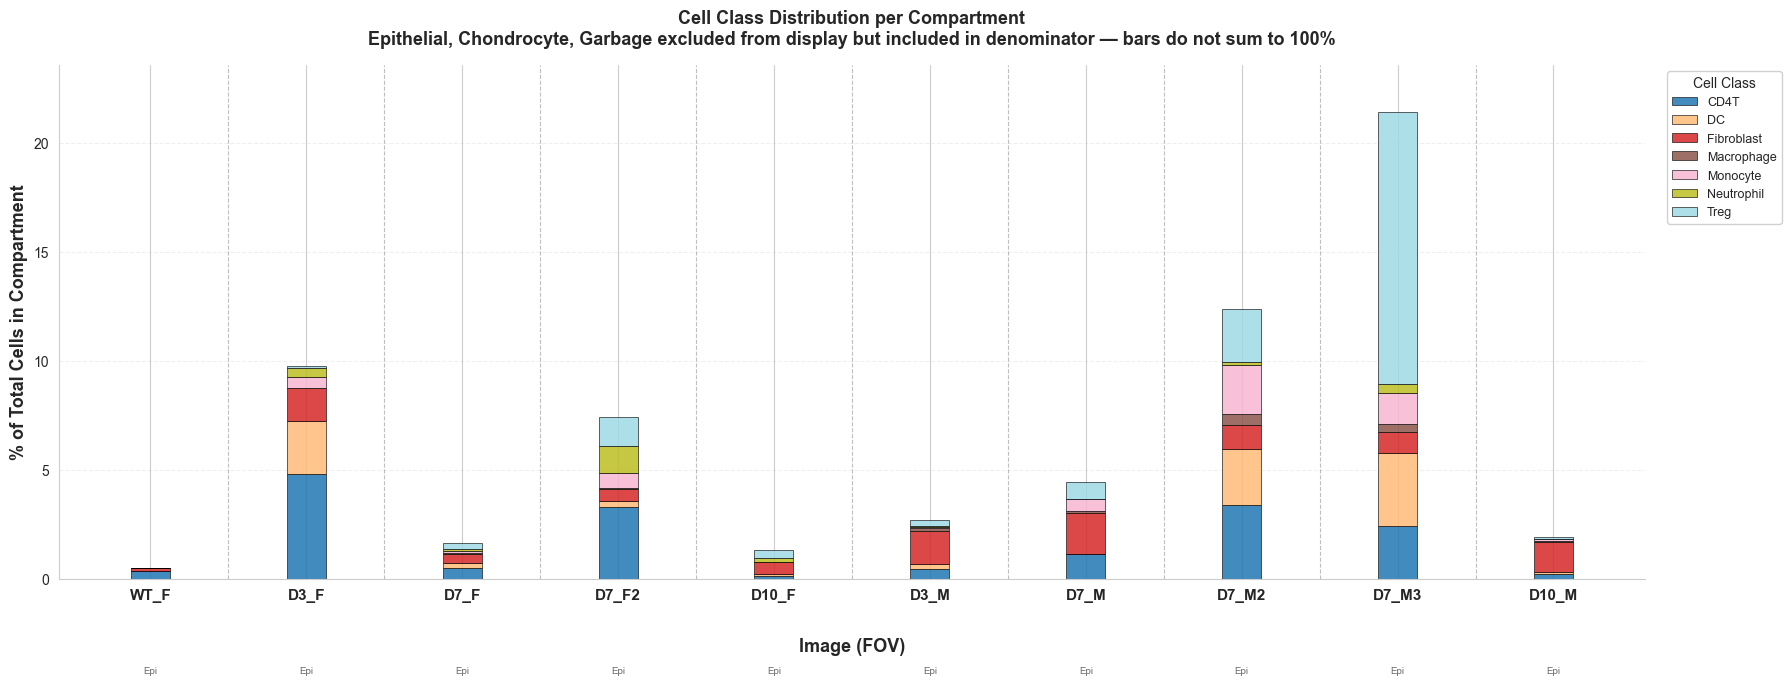

class                  CD4T        DC  Fibroblast  Macrophage  Monocyte  Neutrophil       Treg
fov   compartment                                                                             
D10_F Epidermis    0.121286  0.090964    0.576107    0.000000  0.000000    0.181928   0.333535
D10_M Epidermis    0.242047  0.069156    1.383126    0.034578  0.103734    0.000000   0.103734
D3_F  Epidermis    4.785894  2.434929    1.511335    0.000000  0.503778    0.419815   0.125945
D3_M  Epidermis    0.462107  0.231054    1.478743    0.138632  0.046211    0.046211   0.277264
D7_F  Epidermis    0.500695  0.222531    0.417246    0.027816  0.111266    0.083449   0.278164
D7_F2 Epidermis    3.275401  0.311943    0.534759    0.022282  0.713012    1.225490   1.314617
D7_M  Epidermis    1.152738  0.000000    1.860100    0.078596  0.576369    0.000000   0.759759
D7_M2 Epidermis    3.375286  2.574371    1.115561    0.514874  2.202517    0.143021   2.459954
D7_M3 Epidermis    2.436850  3.328380    0.950966 

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd


def plot_stacked_cell_class_by_compartment(
        counts_df,
        compartments=['Epidermis', 'Dermis', 'BloodVessels'],
        exclude_classes=['Epithelial', 'Chondrocyte'],
        scale_to_plotted=False):

    fov_order = ['WT_F', 'D3_F', 'D7_F', 'D7_F2', 'D10_F', 'D3_M', 'D7_M', 'D7_M2', 'D7_M3', 'D10_M']
    fov_order = [f for f in fov_order if f in counts_df['fov'].values]

    # Filter to relevant compartments
    data = counts_df[counts_df['compartment'].isin(compartments)].copy()

    # Calculate totals BEFORE excluding classes
    compartment_totals = (
        data.groupby(['fov', 'compartment'])['count']
        .sum().reset_index()
        .rename(columns={'count': 'compartment_total'})
    )
    data = data.merge(compartment_totals, on=['fov', 'compartment'])
    data['percentage'] = (data['count'] / data['compartment_total']) * 100

    # Exclude unwanted classes
    data = data[~data['class'].isin(exclude_classes)]

    # Optionally rescale
    if scale_to_plotted:
        plotted_totals = (
            data.groupby(['fov', 'compartment'])['count']
            .sum().reset_index()
            .rename(columns={'count': 'plotted_total'})
        )
        data = data.merge(plotted_totals, on=['fov', 'compartment'])
        data['percentage'] = (data['count'] / data['plotted_total']) * 100

    # Build pivot table
    cell_classes   = sorted(data['class'].unique())
    n_classes      = len(cell_classes)
    n_fovs         = len(fov_order)
    n_compartments = len(compartments)

    pivot = data.pivot_table(
        index=['fov', 'compartment'],
        columns='class',
        values='percentage',
        fill_value=0
    )[cell_classes]

    # After building the pivot table, calculate the max bar height
    max_bar_height = pivot.sum(axis=1).max()

    # Colours
    cmap         = plt.get_cmap('tab20', n_classes)
    class_colors = {cls: cmap(i) for i, cls in enumerate(cell_classes)}

    # Bar positions
    bar_width     = 0.25
    group_spacing = 1.0
    fov_centres   = np.arange(n_fovs) * group_spacing
    offsets       = np.linspace(
        -(n_compartments - 1) * bar_width / 2,
         (n_compartments - 1) * bar_width / 2,
        n_compartments
    )

    # Draw stacked bars — pass label= only on the FIRST fov/compartment
    # so each class gets exactly one legend entry
    fig, ax = plt.subplots(figsize=(max(16, n_fovs * 1.8), 7))

    for fov_idx, fov in enumerate(fov_order):
        for comp_idx, compartment in enumerate(compartments):
            x = fov_centres[fov_idx] + offsets[comp_idx]

            try:
                row = pivot.loc[(fov, compartment)]
            except KeyError:
                row = pd.Series(0, index=cell_classes)

            bottom = 0
            for cls in cell_classes:
                value = row[cls]
                # Only add a label on the very first bar drawn for each class
                # so the legend gets exactly one entry per class
                label = cls if (fov_idx == 0 and comp_idx == 0) else '_nolegend_'
                ax.bar(
                    x, value, bar_width,
                    bottom=bottom,
                    color=class_colors[cls],
                    edgecolor='black',
                    linewidth=0.5,
                    alpha=0.85,
                    label=label
                )
                bottom += value

    # Compartment sub-labels below each bar
    comp_abbrev = {c: c[:3] for c in compartments}
    for fov_idx in range(n_fovs):
        for comp_idx, compartment in enumerate(compartments):
            x = fov_centres[fov_idx] + offsets[comp_idx]
            ax.text(x, -4, comp_abbrev[compartment],
                    ha='center', va='top', fontsize=7, color='dimgray')

    # Axes
    ax.set_xticks(fov_centres)
    ax.set_xticklabels(fov_order, fontsize=11, fontweight='bold')
    ax.set_xlabel('Image (FOV)', fontsize=13, fontweight='bold', labelpad=25)

    if scale_to_plotted:
        ylabel     = '% of Plotted Cells in Compartment'
        title_note = (f'Scaled to plotted classes only\n'
                      f'({", ".join(exclude_classes)} excluded from display and denominator)')
    else:
        ylabel     = '% of Total Cells in Compartment'
        title_note = (f'{", ".join(exclude_classes)} excluded from display '
                      f'but included in denominator — bars do not sum to 100%')

    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_title(
        f'Cell Class Distribution per Compartment\n{title_note}',
        fontsize=13, fontweight='bold', pad=15
    )

    # Vertical dividers between FOV groups
    for i in range(n_fovs - 1):
        ax.axvline(
            x=(fov_centres[i] + fov_centres[i + 1]) / 2,
            color='grey', linewidth=0.8, linestyle='--', alpha=0.5
        )

    ax.set_ylim(0, max_bar_height * 1.1)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend — uses the labels passed directly to ax.bar() above
    ax.legend(
        title='Cell Class',
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        fontsize=9,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.show()

    print(pivot.to_string())
    return pivot


# Run
summary = plot_stacked_cell_class_by_compartment(
    counts_df,
    compartments=['Epidermis'],
    exclude_classes=['Epithelial', 'Chondrocyte', 'Garbage'],
    scale_to_plotted=False
)


## 11. Summary Statistics

In [48]:
# Overall summary
print("="*80)
print("OVERALL SUMMARY")
print("="*80)

print(f"\nTotal FOVs processed: {len(all_fov_data)}")
print(f"Compartments analyzed: {list(COMPARTMENT_MAPPING.values())}")
print(f"Cell classes found: {sorted(counts_df['class'].unique())}")

print("\nTotal cells per compartment (all FOVs):")
for compartment in sorted(counts_df['compartment'].unique()):
    total = counts_df[counts_df['compartment'] == compartment]['count'].sum()
    print(f"  {compartment}: {total}")

print("\nTotal cells per class (all compartments):")
for cell_class in sorted(counts_df['class'].unique()):
    total = counts_df[counts_df['class'] == cell_class]['count'].sum()
    print(f"  {cell_class}: {total}")

OVERALL SUMMARY

Total FOVs processed: 10
Compartments analyzed: ['Epidermis', 'Dermis', 'Cartilage', 'Follicles', 'Blood_vessels']
Cell classes found: ['CD45', 'CD45-', 'vessels_CD45', 'vessels_CD45-']

Total cells per compartment (all FOVs):
  Blood: 2506
  Cartilage: 16529
  Dermis: 43388
  Epidermis: 31154
  Follicles: 8377

Total cells per class (all compartments):
  CD45: 30528
  CD45-: 68920
  vessels_CD45: 1005
  vessels_CD45-: 1501


## 12. Export Data for Further Analysis

In [ ]:
# Export the averaged data
avg_counts.to_csv('average_counts_by_compartment_class.csv', index=False)
print("Average counts saved to 'average_counts_by_compartment_class.csv'")

# Export per-FOV summary
fov_summary = counts_df.groupby(['fov', 'compartment'])['count'].sum().reset_index()
fov_summary.columns = ['fov', 'compartment', 'total_cells']
fov_summary.to_csv('fov_compartment_totals.csv', index=False)
print("Per-FOV compartment totals saved to 'fov_compartment_totals.csv'")